# Grade-Cutoff Bunching: Do Inspection Scores Cluster Right Below the A/B and B/C Thresholds?

## Background

NYC assigns a letter grade from each inspection's numeric SCORE: **A = 0-13 points, B = 14-27 points, C = 28+ points**. If inspectors or restaurant owners have any ability to influence the final score near a cutoff (e.g. an owner contesting a marginal violation before the score is finalized, or an inspector rounding a borderline case down), the underlying distribution of scores should show an unnatural spike right at or below 13 and right at or below 27, relative to a smooth trend -- a pattern known as bunching at a regulatory threshold.

This notebook checks for that pattern directly in the DOHMH inspection scores. Unlike the forest-plot notebooks, this analysis is at the *inspection* level, not the *violation* level -- see the collapsing step below.

**Takes in:** `data/cleaned_inspections.csv` (written by `01_data_pull_clean.ipynb`)

**Outputs:** `output/score_distribution_grade_cutoffs.png`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import utils

A_CUTOFF = 13  # A: 0-13
B_CUTOFF = 27  # B: 14-27, C: 28+


def cutoff_bunching(counts, cutoff, window=3):
    """Compare the count exactly at `cutoff` to the average count in the `window` scores
    just below and just above it. A ratio near 1 means no unusual spike; well above 1
    means excess bunching right at the cutoff relative to its immediate neighbors."""
    at_cutoff = counts.get(cutoff, 0)
    below_avg = counts.reindex(range(cutoff - window, cutoff)).mean()
    above_avg = counts.reindex(range(cutoff + 1, cutoff + 1 + window)).mean()
    return at_cutoff, below_avg, above_avg

## Load cleaned data and collapse to one row per inspection

`data/cleaned_inspections.csv` still has one row per *cited violation* (01 only deduplicates exact-duplicate rows and cleans individual fields), so a single inspection's SCORE is repeated across every violation row from that inspection. Counting violation-rows would over-weight inspections with more violations, so we collapse to one row per (restaurant, inspection date) before looking at the score distribution.

In [2]:
df = utils.load_cleaned(usecols=["camis", "inspection_date", "score"])
df = df.dropna(subset=["score"])
print(f"Rows (violation-level) before collapsing to one row per inspection: {len(df):,}")

inspections = df.drop_duplicates(subset=["camis", "inspection_date"]).copy()
inspections["score"] = inspections["score"].astype(int)
print(f"Rows after collapsing to one row per inspection: {len(inspections):,}")

Loaded 153,452 rows from /Users/ethan/qss20-nyc-restaurant-inspections/data/cleaned_inspections.csv
Rows (violation-level) before collapsing to one row per inspection: 134,855
Rows after collapsing to one row per inspection: 134,836


## Full score distribution with grade cutoffs marked

Max score in data: 151
Inspections scoring > 60 (not shown in plot): 720
Saved plot to /Users/ethan/qss20-nyc-restaurant-inspections/output/score_distribution_grade_cutoffs.png


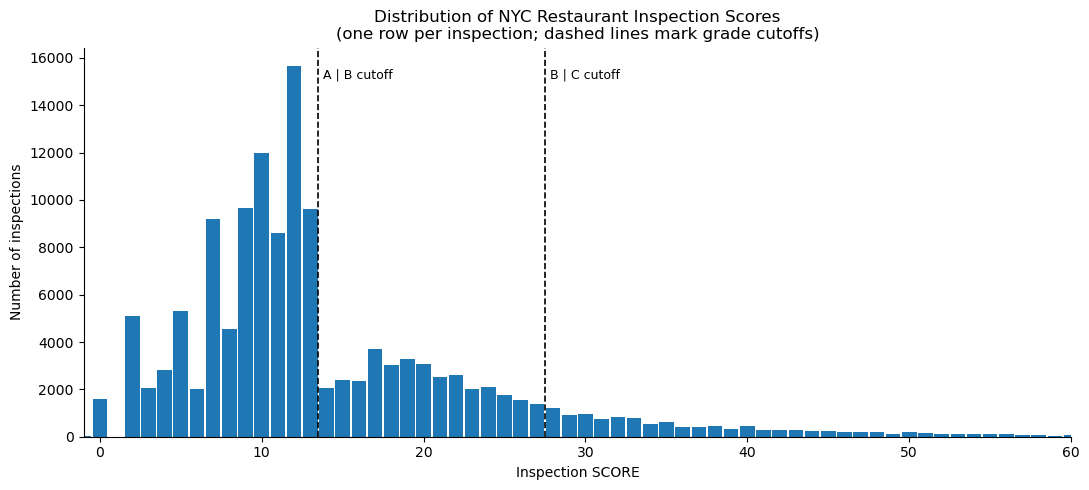

In [3]:
MAX_DISPLAY = 60
counts = inspections["score"].value_counts().sort_index()
print(f"Max score in data: {inspections['score'].max()}")
print(f"Inspections scoring > {MAX_DISPLAY} (not shown in plot): "
      f"{(inspections['score'] > MAX_DISPLAY).sum():,}")

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(counts.index, counts.values, width=0.9, color="#1f77b4")
ax.set_xlim(-1, MAX_DISPLAY)
ymax = ax.get_ylim()[1]
ax.axvline(A_CUTOFF + 0.5, color="black", linestyle="--", linewidth=1.2)
ax.axvline(B_CUTOFF + 0.5, color="black", linestyle="--", linewidth=1.2)
ax.text(A_CUTOFF + 0.8, ymax * 0.92, "A | B cutoff", fontsize=9)
ax.text(B_CUTOFF + 0.8, ymax * 0.92, "B | C cutoff", fontsize=9)
ax.set_xlabel("Inspection SCORE")
ax.set_ylabel("Number of inspections")
ax.set_title("Distribution of NYC Restaurant Inspection Scores\n"
             "(one row per inspection; dashed lines mark grade cutoffs)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
fig.savefig(f"{utils.OUTPUT_DIR}/score_distribution_grade_cutoffs.png", dpi=200)
print(f"Saved plot to {utils.OUTPUT_DIR}/score_distribution_grade_cutoffs.png")
plt.show()

## Quantifying the jump at each cutoff

For each cutoff, compare the number of inspections scoring *exactly* at the cutoff to the average count at the 3 scores just below and the 3 scores just above. A ratio near 1 means no unusual spike; a ratio well above 1 means excess bunching right at the cutoff relative to its immediate neighbors.

In [4]:
for cutoff, label in [(A_CUTOFF, "A/B (13 | 14)"), (B_CUTOFF, "B/C (27 | 28)")]:
    at_cutoff, below_avg, above_avg = cutoff_bunching(counts, cutoff)
    print(
        f"{label}: inspections scoring exactly {cutoff} = {at_cutoff:,} | "
        f"avg of {cutoff - 3}-{cutoff - 1} = {below_avg:,.0f} | "
        f"avg of {cutoff + 1}-{cutoff + 3} = {above_avg:,.0f} | "
        f"ratio (at cutoff / just above) = {at_cutoff / above_avg:.2f}"
    )

A/B (13 | 14): inspections scoring exactly 13 = 9,632 | avg of 10-12 = 12,073 | avg of 14-16 = 2,268 | ratio (at cutoff / just above) = 4.25
B/C (27 | 28): inspections scoring exactly 27 = 1,380 | avg of 24-26 = 1,804 | avg of 28-30 = 1,037 | ratio (at cutoff / just above) = 1.33
